In [14]:
import pandas as pd

df = pd.read_csv(r".\data\data\vendor_invoice.csv")

In [17]:
import pandas as pd

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["PODate"] = pd.to_datetime(df["PODate"])
df["PayDate"] = pd.to_datetime(df["PayDate"])

# Payment delay
df["PaymentDelay"] = (
    df["PayDate"] - df["InvoiceDate"]
).dt.days

# Processing time
df["POProcessingTime"] = (
    df["InvoiceDate"] - df["PODate"]
).dt.days

# Cost per unit
df["CostPerUnit"] = df["Dollars"] / df["Quantity"]


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,PaymentDelay,POProcessingTime,CostPerUnit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN,43,14,35.710000
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN,45,16,9.370000
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN,38,16,21.320000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN,24,23,13.612255
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN,36,14,8.024419


In [19]:
from sklearn.ensemble import IsolationForest

X = df[
    [
        "Quantity",
        "Dollars",
        "Freight",
        "PaymentDelay",
        "POProcessingTime",
        "CostPerUnit"
    ]
]

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

df["FraudFlag"] = model.fit_predict(X)

df["FraudFlag"].value_counts()

FraudFlag
 1    5432
-1     111
Name: count, dtype: int64


In [21]:
vendor_risk = df.groupby("VendorName").agg({
    "Dollars":"sum",
    "Freight":"sum",
    "PaymentDelay":"mean"
})

vendor_risk["RiskScore"] = (
    vendor_risk["PaymentDelay"]*0.4 +
    vendor_risk["Freight"]*0.3 +
    vendor_risk["Dollars"]*0.00001
)

vendor_risk = vendor_risk.sort_values(
    "RiskScore",
    ascending=False
)

vendor_risk

,Dollars,Freight,PaymentDelay,RiskScore
VendorName,,,,
DIAGEO NORTH AMERICA INC,50959796.85,257032.07,35.618182,77633.466241
MARTIGNETTI COMPANIES,27821473.91,144719.92,36.781818,43708.903466
JIM BEAM BRANDS COMPANY,24203151.05,123880.97,35.672727,37420.591601
PERNOD RICARD USA,24124091.56,123780.22,36.072727,37389.736007
BACARDI USA INC,17624378.72,89286.27,34.781818,26976.037514
CONSTELLATION BRANDS INC,15573917.90,79528.99,36.290909,24028.952543
BROWN-FORMAN CORP,13529433.08,68601.68,36.163636,20730.263785
ULTRA BEVERAGE COMPANY LLP,13210613.93,68054.70,35.690909,20562.792503
E & J GALLO WINERY,12289608.09,61966.91,36.545455,18727.587263


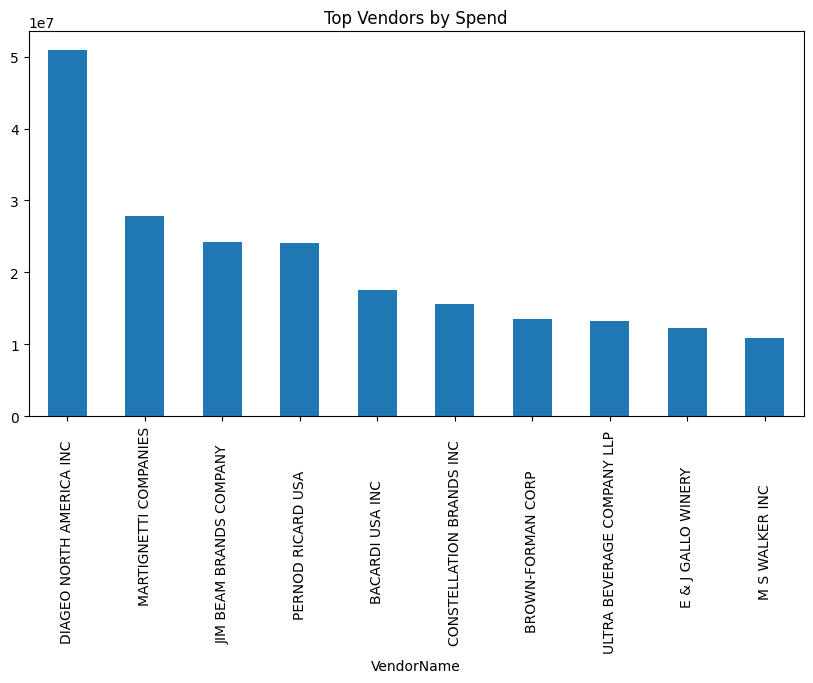

In [22]:
import matplotlib.pyplot as plt

top_vendors = (
    df.groupby("VendorName")["Dollars"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_vendors.plot(kind="bar", figsize=(10,5))

plt.title("Top Vendors by Spend")
plt.show()

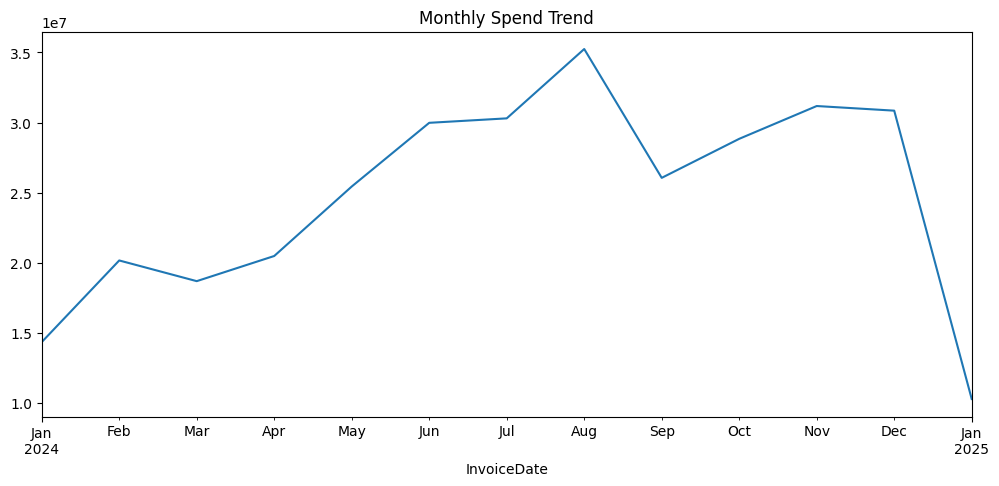

In [23]:
monthly_spend = (
    df.groupby(
        df["InvoiceDate"].dt.to_period("M")
    )["Dollars"]
    .sum()
)

monthly_spend.plot(figsize=(12,5))

plt.title("Monthly Spend Trend")
plt.show()

In [25]:
monthly_spend = (
    df.groupby(
        df["InvoiceDate"].dt.to_period("M")
    )["Dollars"]
    .sum()
    .reset_index()
)

monthly_spend["InvoiceDate"] = range(
    len(monthly_spend)
)

,InvoiceDate,Dollars
0,0,14352430.89
1,1,20171852.18
2,2,18696787.32
3,3,20489328.16
4,4,25441723.82


In [26]:
from sklearn.linear_model import LinearRegression

X = monthly_spend[["InvoiceDate"]]
y = monthly_spend["Dollars"]

model = LinearRegression()

model.fit(X, y)

future_months = pd.DataFrame({
    "InvoiceDate": range(
        len(monthly_spend),
        len(monthly_spend)+6
    )
})

predictions = model.predict(future_months)

print(predictions)

[29012579.81423077 29619863.02362637 30227146.23302197 30834429.44241758
 31441712.65181318 32048995.86120879]


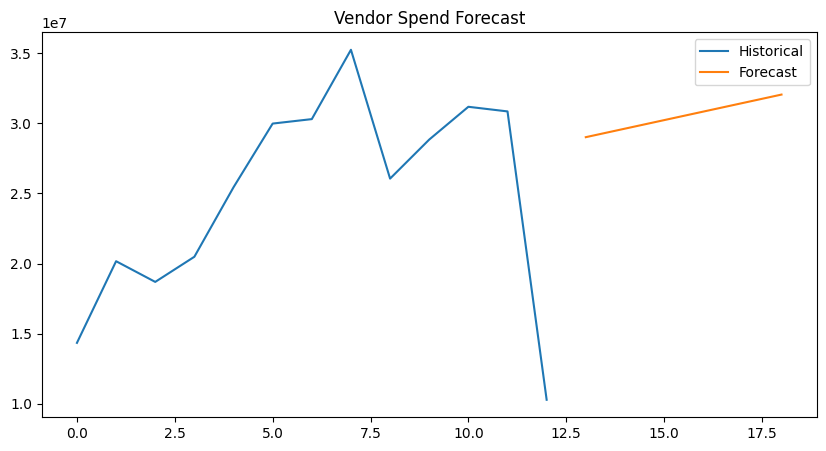

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_spend["InvoiceDate"],
    monthly_spend["Dollars"],
    label="Historical"
)

plt.plot(
    future_months["InvoiceDate"],
    predictions,
    label="Forecast"
)

plt.legend()

plt.title("Vendor Spend Forecast")
plt.show()

In [29]:
vendor_perf = df.groupby("VendorName").agg({
    "Dollars":"sum",
    "Quantity":"sum",
    "PaymentDelay":"mean"
})

vendor_perf["PerformanceScore"] = (
    vendor_perf["Dollars"] * 0.00001 +
    vendor_perf["Quantity"] * 0.0001 -
    vendor_perf["PaymentDelay"] * 0.5
)

vendor_perf = vendor_perf.sort_values(
    "PerformanceScore",
    ascending=False
)

vendor_perf

,Dollars,Quantity,PaymentDelay,PerformanceScore
VendorName,,,,
DIAGEO NORTH AMERICA INC,50959796.85,5459788,35.618182,1037.767678
MARTIGNETTI COMPANIES,27821473.91,2637275,36.781818,523.551330
JIM BEAM BRANDS COMPANY,24203151.05,2737165,35.672727,497.911647
PERNOD RICARD USA,24124091.56,1647558,36.072727,387.960352
CONSTELLATION BRANDS INC,15573917.90,2325892,36.290909,370.182924


In [30]:
df.to_csv(
    "Vendor_Intelligence_Output.csv",
    index=False
)

vendor_risk.to_csv(
    "Vendor_Risk_Report.csv"
)

vendor_perf.to_csv(
    "Vendor_Performance_Report.csv"
)

In [35]:
duplicates = df[
    df.duplicated(
        subset=[
            "VendorNumber",
            "PONumber",
            "Dollars"
        ],
        keep=False
    )
]

duplicates

Duplicate Records: 0


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,PaymentDelay,POProcessingTime,CostPerUnit,FraudFlag
